# 数值分析大作业

对于 $d$ 维积分，可以分离变量：$$I_d = \int_{[0,1]^d} e^{-\sum_{i=1}^d x_i} dx = \prod_{i=1}^d \int_0^1 e^{-x_i} dx_i = \left( [-e^{-x_i}]_0^1 \right)^d = (1 - e^{-1})^d$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['axes.unicode_minus'] = False

def exact_sol(d):
    return (1 - np.exp(-1))**d

def integrand(x):
    if x.ndim == 1:
        return np.exp(-x)
    return np.exp(-np.sum(x, axis=1))

## 第一部分：Monte Carlo 数值积分程序

### 1. 利用 $d=1$ 情形验证 Monte Carlo 方法为半阶收敛（与精确解比较）并与复合梯形法比较。

 - $d=1$ 时，目标积分$$I_1 = \int_0^1 e^{-x} dx$$
 - Monte Carlo 公式：在均匀分布 $U(0,1)$ 中采样 $N$ 个随机点 $x_k$
    $$I_{MC} \approx \frac{1}{N} \sum_{k=1}^N e^{-x_k}$$
    根据中心极限定理，其误差界限为 $O(N^{-1/2})$，即半阶收敛。
 
 - 复合梯形法公式：将区间 $[0,1]$ 等分为 $N$ 份，步长 $h = 1/N$，节点 $x_k = k \cdot h$
    $$I_{Tr} \approx \frac{h}{2} \left[ f(x_0) + 2\sum_{k=1}^{N-1} f(x_k) + f(x_N) \right]$$
    其中 $f(x) = e^{-x}$

    复合梯形法的截断误差为 $O(h^2) = O(N^{-2})$


- 结果分析：Monte Carlo数值积分的特点是：抖动明显，（有时）不单调下降，收敛慢。这是随机性导致的。
- 判断：低维问题中，$O(N^{-2})≫O(N^{−1/2})$，传统数值积分（梯形法）优于 Monte Carlo。

> 说明：幂律在 log-log 下会变成直线，易于验证收敛阶。本小问两种图都展示，剩余题目只使用log-log。

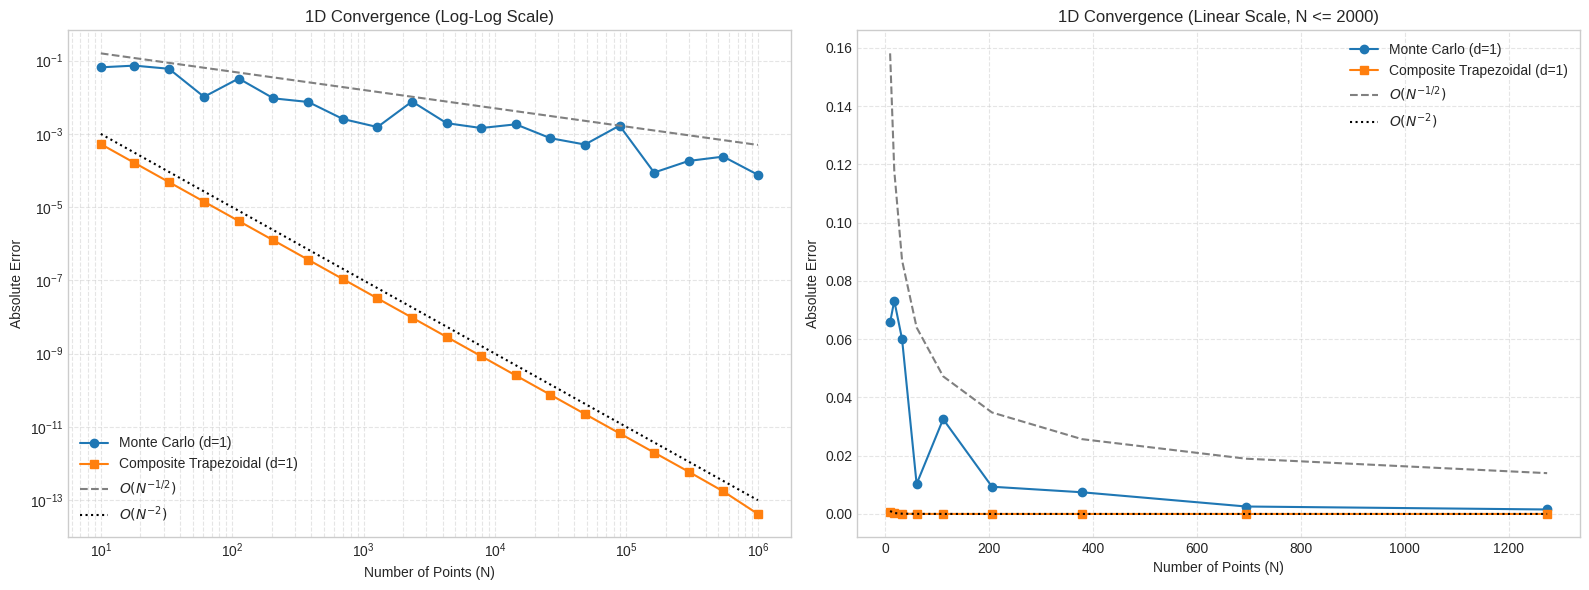

In [28]:
def lin_pick(start, stop, num):
    if num == 1:
        return [float(start)]
    step = (stop - start) / (num - 1)
    return [start + i * step for i in range(num)]

def log_pick(start, stop, num, base=10.0, dtype=float):

    exponents = lin_pick(start, stop, num)
    result = [base ** exp for exp in exponents]
    
    if dtype == int:
        return [int(x) for x in result]
    return result

def trapz_formular(y, x):
    integral = 0.0
    for i in range(len(x) - 1):
        integral += (x[i+1] - x[i]) * (y[i+1] + y[i]) / 2.0
    return integral

N_values_1d = log_pick(1, 6, 20, dtype=int)
errors_mc_1d, errors_trapz_1d = [], []

for N in N_values_1d:
    # 1. Monte Carlo 
    x_mc = np.random.uniform(0, 1, N)
    est_mc = np.mean(integrand(x_mc))
    errors_mc_1d.append(np.abs(est_mc - exact_sol(1)))
    
    # 2. 复合梯形法
    x_trapz = np.array(lin_pick(0, 1, N+1))
    y_trapz = integrand(x_trapz)
    est_trapz = trapz_formular(y_trapz, x_trapz) # 依然使用 Numpy 自带的梯形求积进行比对
    errors_trapz_1d.append(np.abs(est_trapz - exact_sol(1)))


N_arr = np.array(N_values_1d)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Log-Log 坐标轴
ax1.loglog(N_values_1d, errors_mc_1d, 'o-', label='Monte Carlo (d=1)')
ax1.loglog(N_values_1d, errors_trapz_1d, 's-', label='Composite Trapezoidal (d=1)')
ax1.loglog(N_arr, 0.5 * N_arr**(-0.5), '--', color='gray', label='$O(N^{-1/2})$')
ax1.loglog(N_arr, 0.1 * N_arr**(-2.0), ':', color='black', label='$O(N^{-2})$')
ax1.set_title("1D Convergence (Log-Log Scale)")
ax1.set_xlabel("Number of Points (N)")
ax1.set_ylabel("Absolute Error")
ax1.grid(True, which="both", ls="--", alpha=0.5)
ax1.legend()

# 原始坐标轴
N_linear    = [n for n in N_values_1d if n <= 2000]
mc_linear   = [e for n, e in zip(N_values_1d, errors_mc_1d) if n <= 2000]
trapz_linear = [e for n, e in zip(N_values_1d, errors_trapz_1d) if n <= 2000]

N_linear_arr = np.array(N_linear) 
ax2.plot(N_linear, mc_linear, 'o-', label='Monte Carlo (d=1)')
ax2.plot(N_linear, trapz_linear, 's-', label='Composite Trapezoidal (d=1)')
ax2.plot(N_linear_arr, 0.5 * N_linear_arr**(-0.5), '--', color='gray', label='$O(N^{-1/2})$')
ax2.plot(N_linear_arr, 0.1 * N_linear_arr**(-2.0), ':', color='black', label='$O(N^{-2})$')
ax2.set_title("1D Convergence (Linear Scale, N <= 2000)")
ax2.set_xlabel("Number of Points (N)")
ax2.set_ylabel("Absolute Error")
ax2.grid(True, ls="--", alpha=0.5)
ax2.legend()

plt.tight_layout()
plt.show()

### 2.在 $d=2$ 情形与中矩形公式比较。

- $d=2$ 时，目标积分为：

    $$I_2 = \int_0^1 \int_0^1 e^{-(x_1+x_2)} dx_1 dx_2$$

- Monte Carlo 公式：

    二维随机点 $(x_{k,1}, x_{k,2}) \sim U([0,1]^2)$：

    $$I_{MC} \approx \frac{1}{N} \sum_{k=1}^N e^{-(x_{k,1} + x_{k,2})}$$

    其收敛阶依然独立于维度，为 $O(N^{-1/2})$

- 二维矩形公式：

    将 $[0,1] \times [0,1]$ 划分为 $m \times m$ 的均匀网格，总点数 $N = m^2$，步长 $h = 1/m$。取每个子网格的中心点 $(x_i^*, y_j^*) = ((i-0.5)h, (j-0.5)h)$：

    $$I_{Mid} \approx h^2 \sum_{i=1}^m \sum_{j=1}^m e^{-(x_i^* + y_j^*)}$$

    二维矩形公式的误差为 $O(h^2)$，由于 $h = 1/\sqrt{N}$，其关于总节点数 $N$ 的收敛阶为 $O(N^{-1})$

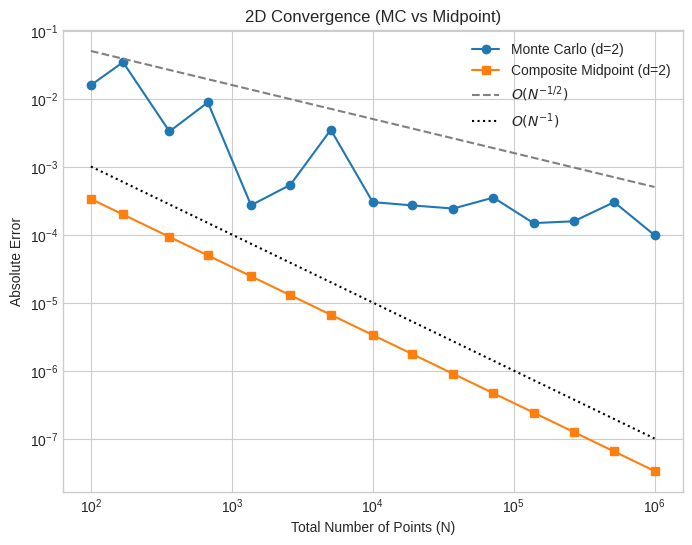

In [30]:
N_grids_2d = np.logspace(1, 3, 15, dtype=int) # 单维度划分数 m
N_values_2d = N_grids_2d ** 2 # 总点数 N = m^2
errors_mc_2d, errors_mid_2d = [], []

for m in N_grids_2d:
    N = m**2
    # Monte Carlo 
    X_mc = np.random.uniform(0, 1, (N, 2))
    est_mc = np.mean(integrand(X_mc))
    errors_mc_2d.append(np.abs(est_mc - exact_sol(2)))
    
    # 复合矩形
    h = 1.0 / m
    x_mid = lin_pick(h/2, 1-h/2, m)
    y_mid = lin_pick(h/2, 1-h/2, m)
    XX, YY = np.meshgrid(x_mid, y_mid)
    Points = np.column_stack([XX.ravel(), YY.ravel()])
    est_mid = h**2 * np.sum(integrand(Points))
    errors_mid_2d.append(np.abs(est_mid - exact_sol(2)))

# 绘图
plt.figure(figsize=(8, 6))
plt.loglog(N_values_2d, errors_mc_2d, 'o-', label='Monte Carlo (d=2)')
plt.loglog(N_values_2d, errors_mid_2d, 's-', label='Composite Midpoint (d=2)')
plt.loglog(N_values_2d, 0.5 * N_values_2d**(-0.5), '--', color='gray', label='$O(N^{-1/2})$')
plt.loglog(N_values_2d, 0.1 * N_values_2d**(-1.0), ':', color='black', label='$O(N^{-1})$')
plt.title("2D Convergence (MC vs Midpoint)")
plt.xlabel("Total Number of Points (N)")
plt.ylabel("Absolute Error")
plt.legend()
plt.show()

### 3. 测试 $d=10$ 情形，画出收敛阶
- $d=10$ 时：
    $$I_{10} = \int_{[0,1]^{10}} e^{-\sum_{i=1}^{10} x_i} d\mathbf{x}$$
- Monte Carlo 公式：$$I_{MC} \approx \frac{1}{N} \sum_{k=1}^N e^{-\sum_{i=1}^{10} x_{k,i}}$$
 
> Remark：网格法已不再适用（若每维分k个点，总计算量 $k^{10}$ 级）; Monte Carlo 的理论误差仍为 $O(N^{-1/2})$ 

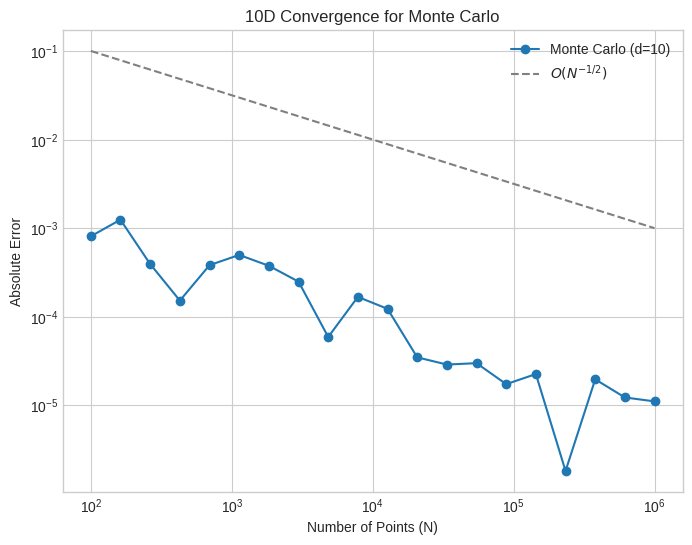

In [33]:
N_values_10d = log_pick(2, 6, 20, dtype=int)
N_values_10d = np.array(N_values_10d)
errors_mc_10d = []

for N in N_values_10d:
    X_mc = np.random.uniform(0, 1, (N, 10))
    est_mc = np.mean(integrand(X_mc))
    errors_mc_10d.append(np.abs(est_mc - exact_sol(10)))

# 绘图
plt.figure(figsize=(8, 6))
plt.loglog(N_values_10d, errors_mc_10d, 'o-', label='Monte Carlo (d=10)')
plt.loglog(N_values_10d, 1.0 * N_values_10d**(-0.5), '--', color='gray', label='$O(N^{-1/2})$')
plt.title("10D Convergence for Monte Carlo")
plt.xlabel("Number of Points (N)")
plt.ylabel("Absolute Error")
plt.legend()
plt.show()

## 二、对于题目一，考虑n=1的情况

### 1. 使用分层(stratified)抽样法进行采样，验证方差减小

- 将区间 $[0,1]$ 划分为 $K$ 个等长子区间，长度为 $\dfrac{1}{K}$。在第 $j$ 层 $[\dfrac{j-1}{K}, \dfrac{j}{K}]$ 中随机均匀采样 $\dfrac{N}{K}$ 个点 $x_{j,i}$。

- 分层抽样估计公式：

    $$I_{Stratified} \approx \sum_{j=1}^K \dfrac{1}{K} \left( \dfrac{1}{N/K} \sum_{i=1}^{N/K} e^{-x_{j,i}} \right)$$

- 由条件方差公式，分层抽样的方差**不超过**标准蒙特卡洛抽样的方差

- 这个小问中，我们对所有情况计算500次积分值求其方差; 子区间个数分别为1（标准MC）, 5，10，15，20; 五种情况都取$10^5$个点。

- 结果分析：随着子区间数量增多，方差大小逐渐减小，和理论一致。K=20时，时间复杂度仍然保持$O(N)$，额外开销低，但是方差减小了三个数量级，显著提高了数值稳定性。

标准 MC 方差: 3.139091e-06

分层抽样 (K= 5) 方差: 1.530339e-07 
分层抽样 (K=10) 方差: 3.861273e-08 
分层抽样 (K=15) 方差: 1.655711e-08 
分层抽样 (K=20) 方差: 8.754211e-09 


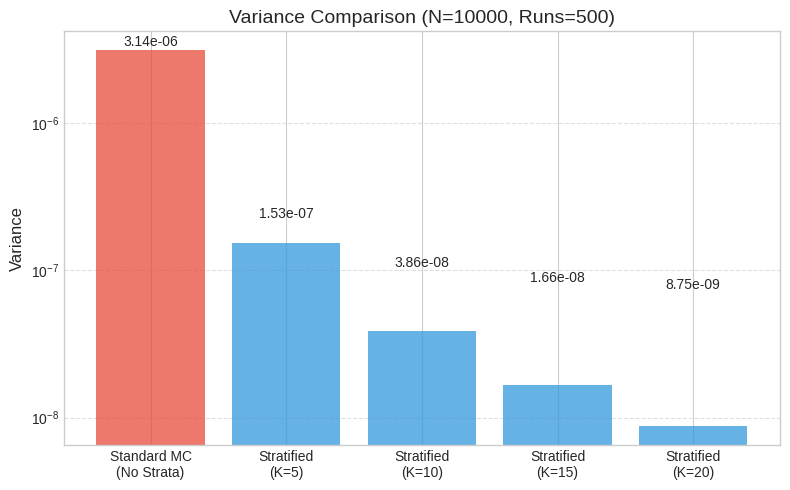

In [39]:
N_test = 10000
mc_runs = 500
K_values = [5, 10, 15, 20]

var_mc_standard = []
for _ in range(mc_runs):
    var_mc_standard.append(np.mean(integrand(np.random.uniform(0, 1, N_test))))

variance_standard = np.var(var_mc_standard)

print(f"标准 MC 方差: {variance_standard:.6e}\n")

variances_stratified = []

for K in K_values:
    N_per_stratum = N_test // K
    var_mc_stratified = []
    
    for _ in range(mc_runs):
        strat_est = 0
        for j in range(K):
            # 在第 j 个子区间均匀采样
            u = np.random.uniform(j/K, (j+1)/K, N_per_stratum)
            strat_est += np.mean(integrand(u)) * (1/K)
        var_mc_stratified.append(strat_est)
        
    current_var = np.var(var_mc_stratified)
    variances_stratified.append(current_var)
    
    print(f"分层抽样 (K={K:2d}) 方差: {current_var:.6e} ")

# 方差柱状图
plt.figure(figsize=(8, 5))

labels = ['Standard MC\n(No Strata)'] + [f'Stratified\n(K={k})' for k in K_values]
variances = [variance_standard] + variances_stratified
bars = plt.bar(labels, variances, alpha=0.75, color=['#e74c3c'] + ['#3498db']*len(K_values))

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (variance_standard*0.02), 
             f'{yval:.2e}', ha='center', va='bottom', fontsize=10)

plt.title(f"Variance Comparison (N={N_test}, Runs={mc_runs})", fontsize=14)
plt.ylabel("Variance", fontsize=12)
plt.yscale('log')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### 2. 选取两种不同的分布，用逆变换法采样，写出采样公式，画出统计图像数学部分（逆变换法）

- 引入概率密度函数$g(x)$，$I = \int_0^1 \frac{e^{-x}}{g(x)} g(x) dx \approx \frac{1}{N} \sum_{k=1}^N \frac{e^{-x_k}}{g(x_k)}, \quad x_k \sim g(x)$

- 逆变换法原理： 计算 $g(x)$ 的累积分布函数（CDF）$G(x) = \int_0^x g(t) dt$。 令 $G(x) = u \sim U(0,1)$，解出 $x = G^{-1}(u)$ 完成采样。

- 分布 A： $g_1(x) = 2x,  x \in [0,1]$ 
    - CDF公式： $G_1(x) = \int_0^x 2t dt = x^2$ 
    - 采样公式： 令 $x^2 = u$，则 $x = \sqrt{u}$

- 分布 B： $g_2(x) = \frac{e^x}{e-1}, x \in [0,1]$
    - CDF公式： $G_2(x) = \int_0^x \frac{e^t}{e-1} dt = \frac{e^x - 1}{e-1}$
    - 采样公式： 令 $\frac{e^x - 1}{e-1} = u \implies e^x = u(e-1) + 1 \implies$ $x = \ln(u(e-1) + 1)$

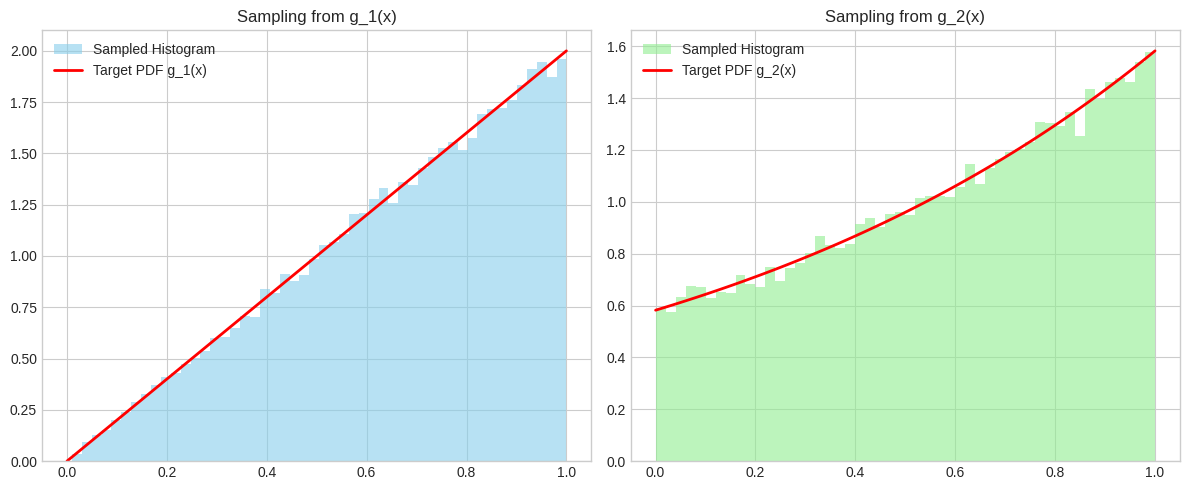

In [42]:
def sample_g1(N):
    u = np.random.uniform(0, 1, N)
    return np.sqrt(u)

def sample_g2(N):
    u = np.random.uniform(0, 1, N)
    return np.log(1 + u * (np.exp(1) - 1))

N_samples = 50000
x_samples_g1 = sample_g1(N_samples)
x_samples_g2 = sample_g2(N_samples)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# g1(x)
axs[0].hist(x_samples_g1, bins=50, density=True, alpha=0.6, color='skyblue', label='Sampled Histogram')
x_plot = np.linspace(0, 1, 100)
axs[0].plot(x_plot, 2*x_plot, 'r-', lw=2, label='Target PDF g_1(x)')
axs[0].set_title("Sampling from g_1(x)")
axs[0].legend()

# g2(x)
axs[1].hist(x_samples_g2, bins=50, density=True, alpha=0.6, color='lightgreen', label='Sampled Histogram')
axs[1].plot(x_plot, np.exp(x_plot)/(np.exp(1)-1), 'r-', lw=2, label='Target PDF g_2(x)')
axs[1].set_title("Sampling from g_2(x)")
axs[1].legend()

plt.tight_layout()
plt.show()

### 3. 对2中不同的分布进行测试，画出相应的收敛阶，并与题目1的情况进行对比。

- 重要性采样的积分估计量（无偏）为：$$I_{IS} = \frac{1}{N} \sum_{i=1}^N \frac{f(X_i)}{g(X_i)}, \quad X_i \sim g(x)$$

- 理论方差为：$$\text{Var}(I_{IS}) = \frac{1}{N} \left[ \int_0^1 \frac{f(x)^2}{g(x)} dx - I^2 \right]$$

    - $\frac{f(x)^2}{g(x)}$ 的积分决定方差大小。
    
- 分布 A：$g_1(x) = 2x$。
    - 考察$\int_0^1 \frac{(e^{-x})^2}{2x} dx = \int_0^1 \frac{e^{-2x}}{2x} dx$， $x \to 0$ ，$e^{-2x} \approx 1 - 2x + \dots$，被积函数渐进 $\frac{1}{2x}$。
    - 由 $\int_0^\epsilon \frac{1}{2x} dx \to \infty$，理论方差发散，导致采样极其不稳定。

- 分布 B：$g_2(x) = \frac{e^x}{e-1}$
    - 考察$$\int_0^1 \frac{(e^{-x})^2}{\frac{e^x}{e-1}} dx = (e-1) \int_0^1 e^{-3x} dx = \frac{e-1}{3} \left[ -e^{-3x} \right]_0^1 = \frac{e-1}{3}(1 - e^{-3})$$ 于是：$$\text{Var}_{g_2}(I_{IS}) = \frac{1}{N} \left[ \frac{e-1}{3}(1 - e^{-3}) - (1 - e^{-1})^2 \right] \approx \frac{0.1447}{N}$$

- 若每种情况作一次实验，最终结果由于随机性，图像呈现锯齿状，于是我们多次独立实验（设置为100次）求均方根误差 (RMSE)，更易于观察收敛阶以及各种方法之间RMSE相对大小。

- 同时，由中心极限定理，方差和RMSE呈现正相关。根据图像，这些情况的误差大小关系是：$$IS(g_1(x))>IS(g_2(x))>\text{StandardMC}>\text{StratifiedMC}$$

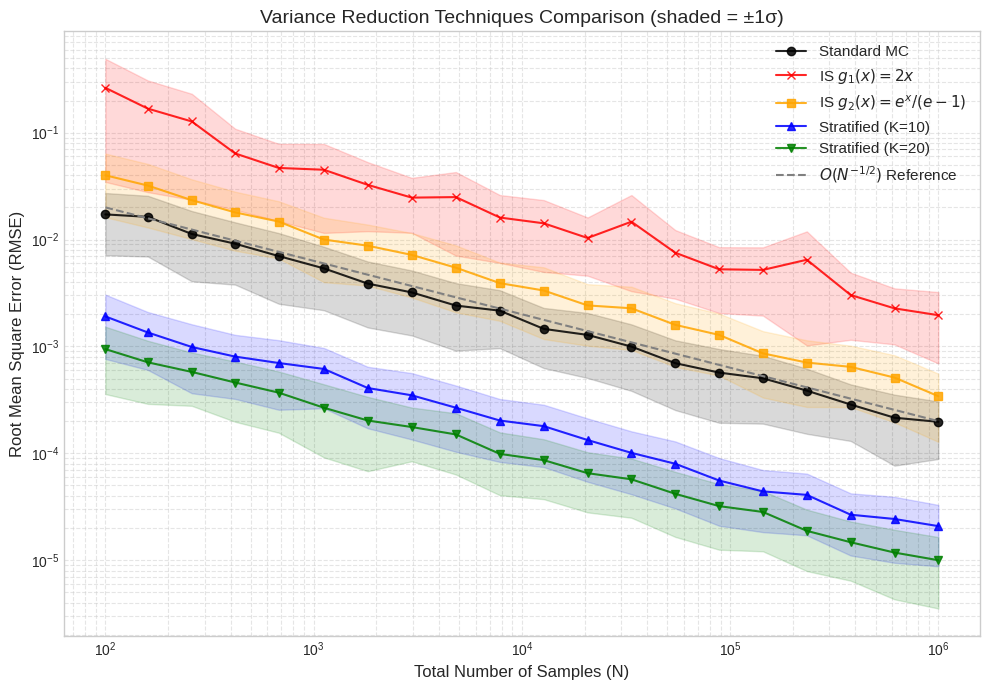

In [ ]:
N_values = np.array([int(n) for n in log_pick(2, 6, 20)])
N_values = np.maximum(N_values - (N_values % 20), 20) 

I_exact = exact_sol(1)

num_trials = 100

rmse_std, rmse_g1, rmse_g2 = [], [], []
rmse_strat_10, rmse_strat_20 = [], []

for N in N_values:

    errs_std, errs_g1, errs_g2, errs_s10, errs_s20 = [], [], [], [], []
    
    for _ in range(num_trials):
        # 1. Standard MC
        x_std = np.random.uniform(0, 1, N)
        errs_std.append(np.mean(integrand(x_std)) - I_exact)
        
        # 2. g1(x)
        x_g1 = sample_g1(N)
        weight_g1 = integrand(x_g1) / (2 * x_g1 + 1e-12) 
        errs_g1.append(np.mean(weight_g1) - I_exact)
        
        # 3. g2(x)
        x_g2 = sample_g2(N)
        weight_g2 = integrand(x_g2) / (np.exp(x_g2) / (np.exp(1) - 1))
        errs_g2.append(np.mean(weight_g2) - I_exact)
        
        # 4. K = 10
        K = 10
        N_per_stratum = N // K
        strat_est_10 = 0
        for j in range(K):
            u = np.random.uniform(j/K, (j+1)/K, N_per_stratum)
            strat_est_10 += np.mean(integrand(u)) * (1/K)
        errs_s10.append(strat_est_10 - I_exact)

        # 5. K = 20
        K = 20
        N_per_stratum = N // K
        strat_est_20 = 0
        for j in range(K):
            u = np.random.uniform(j/K, (j+1)/K, N_per_stratum)
            strat_est_20 += np.mean(integrand(u)) * (1/K)
        errs_s20.append(strat_est_20 - I_exact)

# 收集原始误差
all_errs = {k: [] for k in ['std', 'g1', 'g2', 's10', 's20']}

for N in N_values:
    errs = {k: [] for k in all_errs}

    for _ in range(num_trials):
        # Standard MC
        x_std = np.random.uniform(0, 1, N)
        errs['std'].append(np.mean(integrand(x_std)) - I_exact)

        # IS g1
        x_g1 = sample_g1(N)
        errs['g1'].append(np.mean(integrand(x_g1) / (2 * x_g1 + 1e-12)) - I_exact)

        # IS g2
        x_g2 = sample_g2(N)
        errs['g2'].append(np.mean(integrand(x_g2) / (np.exp(x_g2) / (np.exp(1) - 1))) - I_exact)

        # Stratified K=10
        strat_est = sum(np.mean(integrand(np.random.uniform(j/10, (j+1)/10, N//10))) / 10
                        for j in range(10))
        errs['s10'].append(strat_est - I_exact)

        # Stratified K=20
        strat_est = sum(np.mean(integrand(np.random.uniform(j/20, (j+1)/20, N//20))) / 20
                        for j in range(20))
        errs['s20'].append(strat_est - I_exact)

    for k in all_errs:
        all_errs[k].append(np.array(errs[k]))

# RMSE + σ
def rmse_sigma(err_runs):
    """err_runs: list of arrays, 每个 N 一个 array"""
    rmse  = np.array([np.sqrt(np.mean(e**2))   for e in err_runs])
    sigma = np.array([np.std(np.abs(e))         for e in err_runs])
    return rmse, sigma

stats = {k: rmse_sigma(all_errs[k]) for k in all_errs}

# 绘图
SERIES = [
    ('std', 'o-', 'black',  'Standard MC'),
    ('g1',  'x-', 'red',    r'IS $g_1(x)=2x$'),
    ('g2',  's-', 'orange', r'IS $g_2(x)=e^x/(e-1)$'),
    ('s10', '^-', 'blue',   'Stratified (K=10)'),
    ('s20', 'v-', 'green',  'Stratified (K=20)'),
]

fig, ax = plt.subplots(figsize=(10, 7))

for key, marker, color, label in SERIES:
    rmse, sigma = stats[key]
    lo = np.maximum(rmse - sigma, 1e-16)   # log 坐标防负值
    hi = rmse + sigma
    ax.loglog(N_values, rmse, marker, color=color, alpha=0.85, label=label)
    ax.fill_between(N_values, lo, hi, color=color, alpha=0.15)

ax.loglog(N_values, 0.2 * N_values**(-0.5), '--', color='gray', label=r'$O(N^{-1/2})$ Reference')
ax.set_title("Variance Reduction Techniques Comparison (shaded = ±1σ)", fontsize=14)
ax.set_xlabel("Total Number of Samples (N)", fontsize=12)
ax.set_ylabel("Root Mean Square Error (RMSE)", fontsize=12)
ax.grid(True, which="both", ls="--", alpha=0.5)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

> Remark：尽管计算了 10 次平均的RMSE，红线依然呈现较明显锯齿状。因为它的理论方差是无穷大，大数定律在某种程度上失效了，异常极值依然使之波动。